In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/my_PRML'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/my_PRML.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/my_PRML
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/my_PRML/2
    print("準備完了！このまま下のセルを実行できます。")

# 2.5 ノンパラメトリック法 (Nonparametric Methods)
本ノートブックでは、特定の関数形を仮定せず、データそのものから柔軟に確率密度を推定する**ノンパラメトリック密度推定法**を学びます。

### 本ノートブックの構成:
1. **カーネル密度推定量 (Kernel Density Estimator / Parzen Window)**: ガウス・箱型・エパネチニコフカーネル
2. **バンド幅 (Bandwidth) の選択**: アンダーフィッティングとオーバーフィッティング、シルバマンの経験則
3. **K近傍法 (K-Nearest Neighbours Density Estimation)**: データ密度に応じた適応的解像度
4. **KNN分類器と決定境界**: パラメータ $K$ による決定領域の平滑化と汎化性能

## 2.5.1 カーネル密度推定 (Parzen Window)

データ点 $\mathbf{x}_n$ を中心とする局所領域の確率密度をカーネル関数 $k(\cdot)$ で重ね合わせます。
$$ p(\mathbf{x}) = \frac{1}{N} \sum_{n=1}^N \frac{1}{h^D} k\left( \frac{\mathbf{x} - \mathbf{x}_n}{h} \right) $$
ここで $h$ はバンド幅 (bandwidth) です。

Plot saved to: result/fig2_parzen_kernel_comparison.png


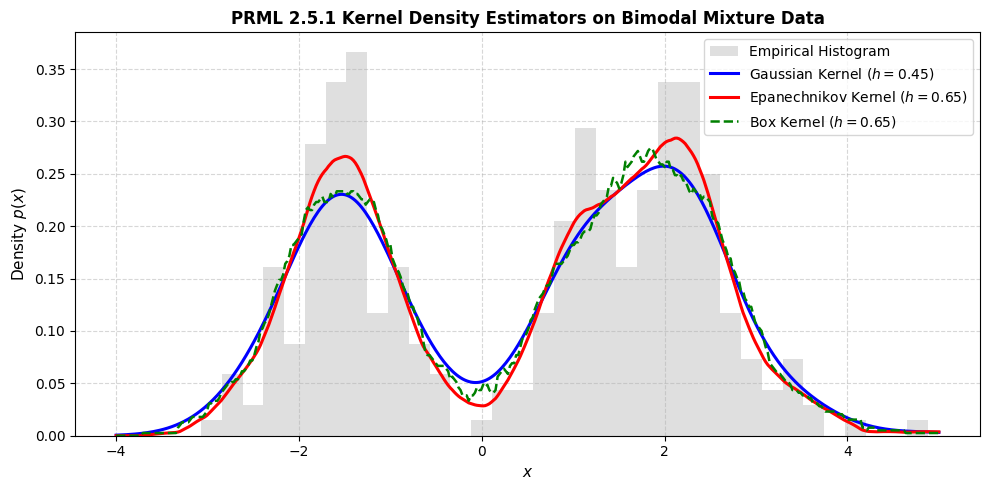

In [1]:
# 様々なカーネル関数による混合ガウスデータの密度推定比較
import sys, os
sys.path.append(os.path.abspath('../'))
os.makedirs("result", exist_ok=True)
from common.plot_utils import save_plot, setup_style
setup_style()

import numpy as np
import matplotlib.pyplot as plt
from prml.distributions import KernelDensityEstimator

np.random.seed(42)
data = np.concatenate([np.random.normal(-1.5, 0.6, 120), np.random.normal(1.8, 0.8, 180)])
x_eval = np.linspace(-4, 5, 400)

kde_gauss = KernelDensityEstimator(bandwidth=0.45, kernel='gaussian').fit(data)
kde_box = KernelDensityEstimator(bandwidth=0.65, kernel='box').fit(data)
kde_epan = KernelDensityEstimator(bandwidth=0.65, kernel='epanechnikov').fit(data)

fig = plt.figure(figsize=(10, 5))
plt.hist(data, bins=35, density=True, alpha=0.25, color='gray', label='Empirical Histogram')
plt.plot(x_eval, kde_gauss.score_samples(x_eval), 'b-', lw=2.2, label='Gaussian Kernel ($h=0.45$)')
plt.plot(x_eval, kde_epan.score_samples(x_eval), 'r-', lw=2.2, label='Epanechnikov Kernel ($h=0.65$)')
plt.plot(x_eval, kde_box.score_samples(x_eval), 'g--', lw=1.8, label='Box Kernel ($h=0.65$)')

plt.title('PRML 2.5.1 Kernel Density Estimators on Bimodal Mixture Data', fontsize=12, fontweight='bold')
plt.xlabel('$x$', fontsize=11)
plt.ylabel('Density $p(x)$', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10)
plt.tight_layout()
save_plot(fig, "result", "fig2_parzen_kernel_comparison.png")
plt.show()

Plot saved to: result/fig2_kde_bandwidth.png


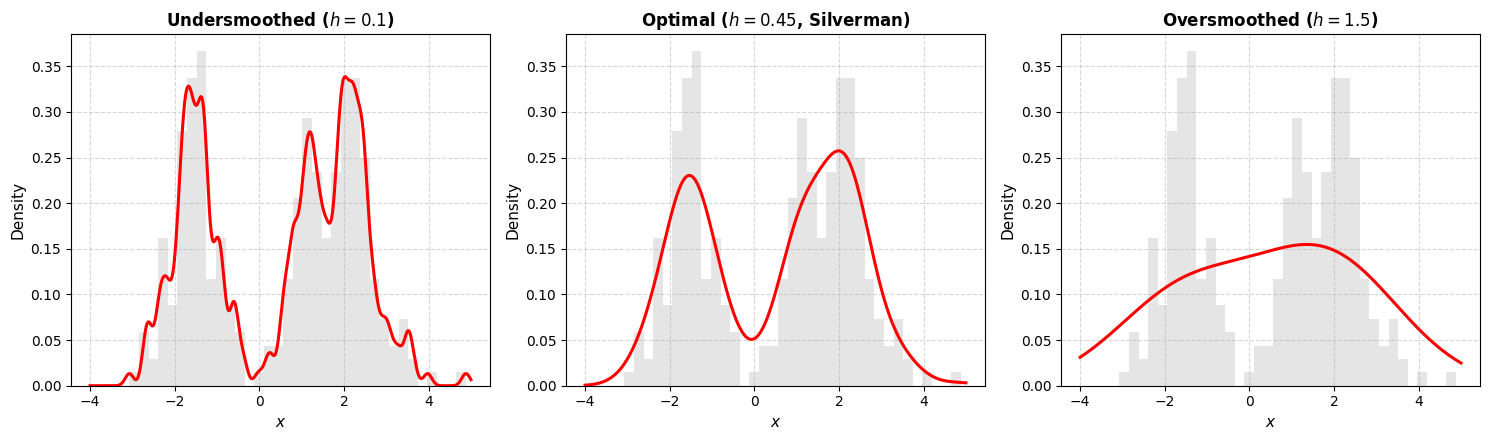

In [2]:
# バンド幅 h の影響: アンダー平滑化 vs 最適 vs オーバー平滑化 (PRML Fig 2.24)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
hs = [0.1, 0.45, 1.5]
titles = [r'Undersmoothed ($h=0.1$)', r'Optimal ($h=0.45$, Silverman)', r'Oversmoothed ($h=1.5$)']

for ax, h, title in zip(axes, hs, titles):
    kde = KernelDensityEstimator(bandwidth=h, kernel='gaussian').fit(data)
    ax.hist(data, bins=35, density=True, alpha=0.2, color='gray')
    ax.plot(x_eval, kde.score_samples(x_eval), 'r-', lw=2.2)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('$x$', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
save_plot(fig, "result", "fig2_kde_bandwidth.png")
plt.show()

## 2.5.2 K近傍法 (K-Nearest Neighbours Density Estimation)

各点 $\mathbf{x}$ を中心に $K$ 個の訓練データを含む最小超球の体積 $V(\mathbf{x})$ を求め、密度を推定します。
$$ p(\mathbf{x}) = \frac{K}{N V(\mathbf{x})} $$

Plot saved to: result/fig2_knn_density_vs_kde.png


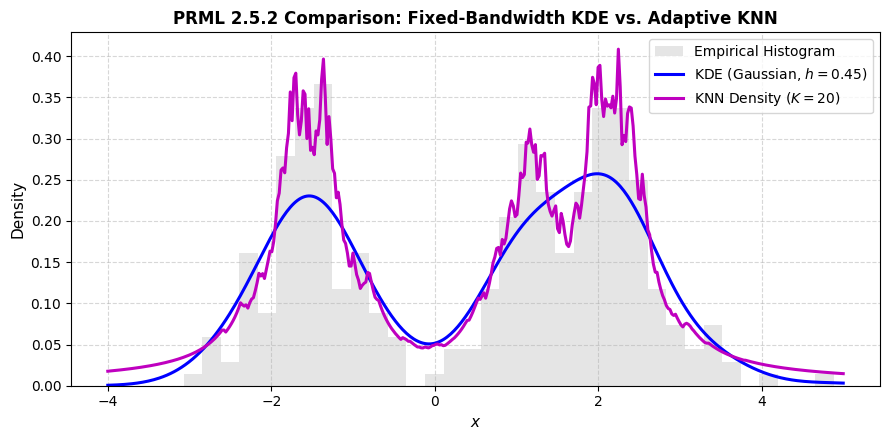

In [3]:
# KDE (固定バンド幅) と KNN (適応的体積) の密度推定比較
from prml.distributions import KNearestNeighborsDensity

knn_dense = KNearestNeighborsDensity(k=20).fit(data)

fig = plt.figure(figsize=(9, 4.5))
plt.hist(data, bins=35, density=True, alpha=0.2, color='gray', label='Empirical Histogram')
plt.plot(x_eval, kde_gauss.score_samples(x_eval), 'b-', lw=2.2, label='KDE (Gaussian, $h=0.45$)')
plt.plot(x_eval, knn_dense.score_samples(x_eval), 'm-', lw=2.2, label='KNN Density ($K=20$)')
plt.title('PRML 2.5.2 Comparison: Fixed-Bandwidth KDE vs. Adaptive KNN', fontsize=12, fontweight='bold')
plt.xlabel('$x$', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10)
plt.tight_layout()
save_plot(fig, "result", "fig2_knn_density_vs_kde.png")
plt.show()

Plot saved to: result/fig2_knn_decision_boundary.png


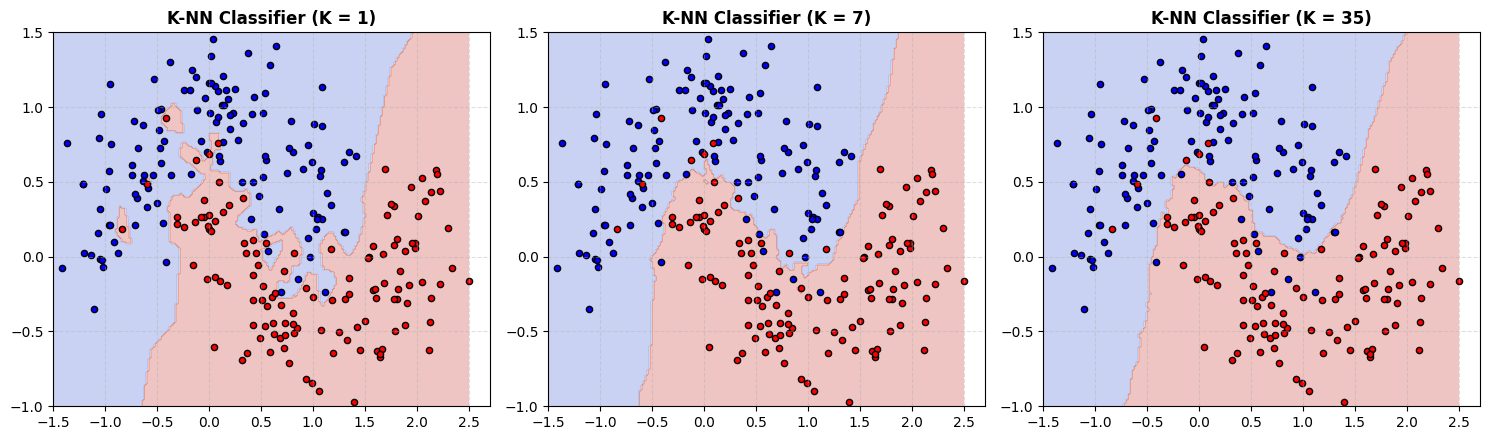

In [4]:
# 2次元非線形分類問題における KNN 決定境界の可視化 (PRML Fig 2.26)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import make_moons

np.random.seed(42)
X_moons, y_moons = make_moons(n_samples=250, noise=0.25, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
Ks = [1, 7, 35]

gx = np.linspace(-1.5, 2.5, 200)
gy = np.linspace(-1.0, 1.5, 200)
GX, GY = np.meshgrid(gx, gy)
grid_pts = np.c_[GX.ravel(), GY.ravel()]

for ax, k in zip(axes, Ks):
    clf = KNeighborsClassifier(n_neighbors=k).fit(X_moons, y_moons)
    Z_cls = clf.predict(grid_pts).reshape(GX.shape)
    
    ax.contourf(GX, GY, Z_cls, alpha=0.3, cmap='coolwarm')
    ax.scatter(X_moons[y_moons==0, 0], X_moons[y_moons==0, 1], c='blue', s=20, edgecolors='k', label='Class 0')
    ax.scatter(X_moons[y_moons==1, 0], X_moons[y_moons==1, 1], c='red', s=20, edgecolors='k', label='Class 1')
    ax.set_title(f'K-NN Classifier (K = {k})', fontsize=12, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
save_plot(fig, "result", "fig2_knn_decision_boundary.png")
plt.show()

## まとめ
1. カーネル密度推定は各データ点をカーネル関数で滑らかに重ね合わせる手法であり、バンド幅 $h$ の適切な調整が本質的である。
2. K近傍法は近傍点の探索半径をデータ密度に応じて伸縮させる適応的解像度を持ち、次元の呪いへの耐性も高い。
3. ノンパラメトリック法は訓練データをすべて保持・参照する必要があるため、計算量やメモリ消費量は $O(N)$ となるトレードオフがある。